# Web App Back End Tests

Tests for the back end of the Structure Relations web application.
Uses *RS.GJS_Struct_Tests.BRBL BH.dcm* file located in the *test_data* folder.

## 1. Import Required Libraries

First, let's import the necessary libraries including our custom DicomStructureFile class.

In [1]:
# Import required libraries
from typing import List, Tuple
#import sys
from pathlib import Path
from pprint import pprint

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shapely

# Add the src directory to the Python path
#sys.path.append('src')

# Import our custom DicomStructureFile class
from dicom import DicomStructureFile

# Import related classes
from types_and_classes import SliceIndexType
from contours import ContourPoints
from contour_plotting import plot_roi_slice

from structure_set import StructureSet
from relations import DE27IM, RelationshipType

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
%matplotlib inline

In [3]:
# Define the path to the test DICOM file
tests_dir = Path.cwd() / r'Tests'
tests_dir = tests_dir.resolve()
test_file_name = 'RS.GJS_Struct_Tests.BRBL BH.dcm'

print(f"=== Loading DICOM file ===: {test_file_name}")
dicom_file = DicomStructureFile(
    top_dir=tests_dir,
    file_name=test_file_name
)
filtered_contours = dicom_file.filter_exclusions()

structure_set = StructureSet(dicom_structure_file=dicom_file)

INFO:dicom:Successfully loaded DICOM dataset from RS.GJS_Struct_Tests.BRBL BH.dcm


=== Loading DICOM file ===: RS.GJS_Struct_Tests.BRBL BH.dcm


INFO:dicom:Extracted 626 contours from 10 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.GJS_Struct_Tests.BRBL BH.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.1 cm/pixel
INFO:dicom:Calculated resolution from structure 'BODY': 0.1 cm/pixel
INFO:dicom:Filtered 0 contours from 1 excluded ROIs. Remaining: 626 contours from 9 ROIs
INFO:structure_set:Building StructureSet from 626 contour points
INFO:structure_set:Calculating relationships for 9 structures
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: invalid value encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.

In [4]:
s = structure_set.summary()
s
s.columns

Index(['ROI', 'Name', 'Physical_Volume', 'Exterior_Volume', 'Hull_Volume',
       'Num_Contours', 'Num_Regions', 'Num_Slices', 'Slice_Range',
       'StructureName', 'DICOM_Type', 'Code', 'CodeScheme', 'CodeMeaning'],
      dtype='object')

In [5]:
row_rois = col_rois = [9, 11, 12, 13, 14, 17, 18, 19, 20]
matrix = structure_set.get_relationship_matrix(row_rois, col_rois,
                                               use_symbols=False)
print(matrix)

Structure_A       BODY    Cavity CTV Cavity   eval PTV PTV Cavity     Heart  \
Structure_B                                                                   
BODY            Equals   Unknown    Unknown    Unknown   Overlaps   Unknown   
Cavity        Contains    Equals  Partition  Partition   Contains  Disjoint   
CTV Cavity    Contains   Unknown     Equals  Partition   Contains  Disjoint   
eval PTV      Contains   Unknown    Unknown     Equals  Partition  Disjoint   
PTV Cavity    Overlaps   Unknown    Unknown    Unknown     Equals  Disjoint   
Heart         Contains  Disjoint   Disjoint   Disjoint   Disjoint    Equals   
Lung B       Partition  Disjoint   Disjoint   Disjoint   Disjoint   Borders   
Lung L       Partition  Disjoint   Disjoint   Disjoint   Disjoint   Borders   
Lung R       Partition  Disjoint   Disjoint   Disjoint   Disjoint   Borders   

Structure_A     Lung B    Lung L    Lung R  
Structure_B                                 
BODY           Unknown   Unknown   Unkno

In [6]:
roi_a = 14
roi_b = 11

tolerance = structure_set.tolerance
composite_relation = DE27IM()

structure_a = structure_set.structures[14]
structure_b = structure_set.structures[11]

complete_relation = structure_a.relate(structure_b)
print(complete_relation)
print(complete_relation.identify_relation())
print()
row_rois = col_rois = [roi_a, roi_b]
matrix = structure_set.get_relationship_matrix(row_rois, col_rois,
                                               use_symbols=False)
print(matrix)

|111|	|111|	|111|
|001|	|001|	|001|
|001|	|001|	|001|

Relationship: Contains

Structure_A PTV Cavity   Cavity
Structure_B                    
PTV Cavity      Equals  Unknown
Cavity        Contains   Equals


In [7]:
roi_a = 14
roi_b = 11

tolerance = structure_set.tolerance
composite_relation = DE27IM()

structure_a = structure_set.structures[14]
structure_b = structure_set.structures[11]

slices_a = set(structure_a.region_table['SliceIndex'])
slices_b = set(structure_b.region_table['SliceIndex'])
used_slices = slices_a | slices_b
both_slices = slices_a & slices_b

pprint(', '.join([f'{s}' for s in sorted(both_slices)]))

print(f'Range is from {min(used_slices)} to {max(used_slices)}')
print(f'Range for both slices is from {min(both_slices)} to {max(both_slices)}')


('-0.625, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, '
 '2.5, 2.75, 3.0, 3.25, 3.5, 3.625')
Range is from -2.125 to 5.125
Range for both slices is from -0.625 to 3.625


|011|	|000|	|000|
|001|	|000|	|000|
|001|	|000|	|000|

Relationship: Unknown


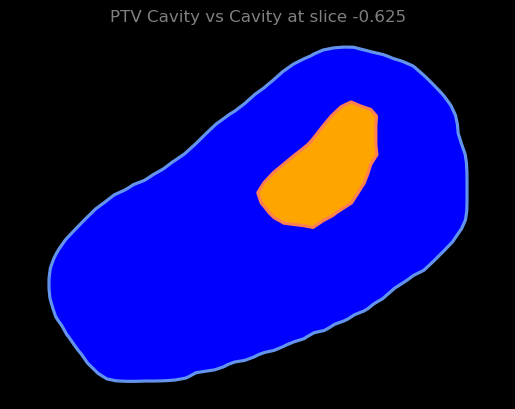

In [8]:
slice = -0.625

slice_a = structure_a.get_slice(slice_index=slice)
slice_b = structure_b.get_slice(slice_index=slice)

relation = DE27IM(slice_a, slice_b, tolerance=tolerance)
composite_relation.merge(relation)
print(relation)
print(relation.identify_relation())
ax = plot_roi_slice(structure_set, slice_index=slice,
                    roi_list=[roi_a, roi_b], tolerance=tolerance)

|111|	|111|	|111|
|001|	|001|	|001|
|001|	|001|	|001|

Relationship: Contains


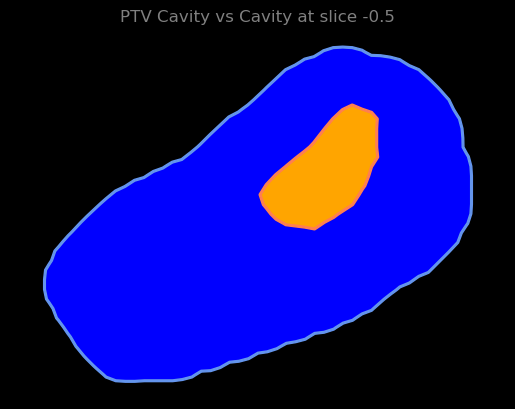

In [9]:
slice = -0.5

slice_a = structure_a.get_slice(slice_index=slice)
slice_b = structure_b.get_slice(slice_index=slice)

relation = DE27IM(slice_a, slice_b, tolerance=tolerance)
composite_relation.merge(relation)
print(relation)
print(relation.identify_relation())
ax = plot_roi_slice(structure_set, slice_index=slice,
                    roi_list=[roi_a, roi_b], tolerance=tolerance)

|011|	|000|	|000|
|001|	|000|	|000|
|001|	|000|	|000|

Relationship: Unknown


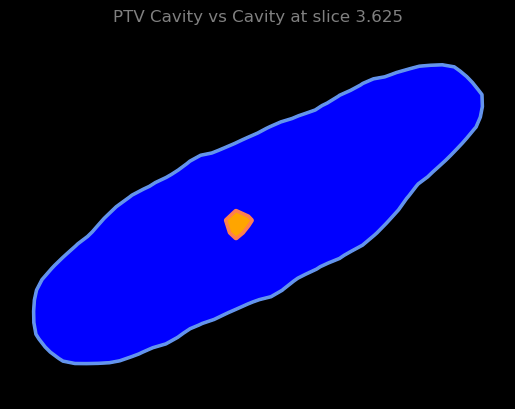

In [10]:
slice = 3.625

slice_a = structure_a.get_slice(slice_index=slice)
slice_b = structure_b.get_slice(slice_index=slice)

relation = DE27IM(slice_a, slice_b, tolerance=tolerance)
composite_relation.merge(relation)
print(relation)
print(relation.identify_relation())
ax = plot_roi_slice(structure_set, slice_index=slice,
                    roi_list=[roi_a, roi_b], tolerance=tolerance)

|001|	|001|	|001|
|001|	|001|	|001|
|001|	|001|	|001|

Relationship: Unknown


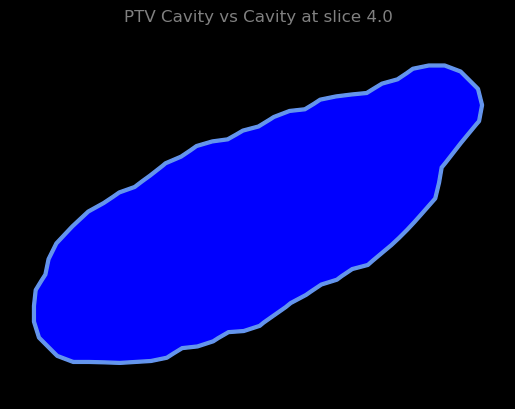

In [11]:
slice = 4.0

slice_a = structure_a.get_slice(slice_index=slice)
slice_b = structure_b.get_slice(slice_index=slice)

relation = DE27IM(slice_a, slice_b, tolerance=tolerance)
composite_relation.merge(relation)
print(relation)
print(relation.identify_relation())
ax = plot_roi_slice(structure_set, slice_index=slice,
                    roi_list=[roi_a, roi_b], tolerance=tolerance)

In [12]:
print(composite_relation)
print(composite_relation.identify_relation())

|111|	|111|	|111|
|001|	|001|	|001|
|001|	|001|	|001|

Relationship: Contains
